# 02. Dataset QC and Filtering

This notebook checks the quality of the matched cryo/ambient PDB pair dataset created in `01_mine_pdb_pairs`.

The goal is to make sure the dataset is biologically and computationally reasonable before training a deep learning model. Specifically, this notebook checks:

1. Whether cryo and ambient structures have appropriate temperatures.
2. Whether matched structures have similar resolution and crystal unit cells.
3. Whether enough residues are modeled in both structures to support continuous B-factor difference labels.
4. Whether the binary "ambient modeled but cryo missing" label is common enough to be useful.
5. Whether obvious noisy pairs should be removed before modeling.
6. Whether train/validation/test splits should avoid homolog leakage, not just duplicate UniProt IDs.

The output is a cleaned manifest file that can be used in the ESM embedding and modeling notebooks.

In [1]:
from pathlib import Path
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## 1. Set paths and load the manifest

The first notebook saved one row per matched cryo/ambient pair in `data/manifest.csv`.

If this path does not work, update `DATA_DIR` to point to the same `data/` directory created by notebook 01.

In [ ]:
# Adjust this only if needed
DATA_DIR = Path("data")

MANIFEST_PATH = DATA_DIR / "manifest.csv"
LABEL_DIR = DATA_DIR / "labels"
SEQ_DIR = DATA_DIR / "sequences"

assert MANIFEST_PATH.exists(), f"Could not find manifest at {MANIFEST_PATH}"
assert LABEL_DIR.exists(), f"Could not find labels directory at {LABEL_DIR}"
assert SEQ_DIR.exists(), f"Could not find sequences directory at {SEQ_DIR}"

manifest = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", manifest.shape)
print("Columns:")
print(manifest.columns.tolist())

manifest.head()

DATA_DIR
Manifest shape: (1162, 25)
Columns:
['pair_id', 'uniprot', 'pdb_cryo', 'chain_cryo', 'pdb_ambient', 'chain_ambient', 'space_group', 'cell_a_cryo', 'cell_b_cryo', 'cell_c_cryo', 'cell_a_ambient', 'cell_b_ambient', 'cell_c_ambient', 'max_cell_dev_pct', 'resolution_cryo', 'resolution_ambient', 'temp_cryo', 'temp_ambient', 'n_residues', 'n_modeled_both', 'n_only_ambient', 'n_only_cryo', 'aa_disagreements', 'labels_path', 'sequence_path']


,pair_id,uniprot,pdb_cryo,chain_cryo,pdb_ambient,chain_ambient,space_group,cell_a_cryo,cell_b_cryo,cell_c_cryo,cell_a_ambient,cell_b_ambient,cell_c_ambient,max_cell_dev_pct,resolution_cryo,resolution_ambient,temp_cryo,temp_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo,aa_disagreements,labels_path,sequence_path
0,A0A075B6C4_7N5P_7N4K,A0A075B6C4,7N5P,D,7N4K,D,P 1 21 1,54.334,72.056,107.671,54.140,72.530,107.720,0.653523,2.09,1.85,100.0,277.00,196,195,1,0,0,labels\A0A075B6C4_7N5P_7N4K.npz,sequences\A0A075B6C4.fasta
1,A0A086IRG1_9RQ3_9S5B,A0A086IRG1,9RQ3,A,9S5B,A,P 21 21 2,68.278,89.802,44.974,69.280,90.830,45.260,1.446305,1.22,1.50,100.0,296.00,138,137,1,0,0,labels\A0A086IRG1_9RQ3_9S5B.npz,sequences\A0A086IRG1.fasta
2,A0A0A1EQY0_8HTY_8IQ7,A0A0A1EQY0,8HTY,A,8IQ7,A,P 1,54.132,68.959,109.792,54.668,69.509,110.800,0.980464,1.40,2.10,100.0,298.00,356,356,0,0,0,labels\A0A0A1EQY0_8HTY_8IQ7.npz,sequences\A0A0A1EQY0.fasta
3,A0A0C3QM78_9H06_9H07,A0A0C3QM78,9H06,A,9H07,A,P 43 21 2,59.971,59.971,231.864,59.959,59.959,231.749,0.049598,1.86,2.41,100.0,293.00,235,226,0,9,0,labels\A0A0C3QM78_9H06_9H07.npz,sequences\A0A0C3QM78.fasta
4,A0A0E1CQ35_9G1M_9G1E,A0A0E1CQ35,9G1M,A,9G1E,A,P 21 21 2,68.150,89.792,44.998,69.350,90.880,45.300,1.730353,1.18,1.40,100.0,296.15,137,137,0,0,0,labels\A0A0E1CQ35_9G1M_9G1E.npz,sequences\A0A0E1CQ35.fasta


## 2. Basic dataset summary

Before filtering, I want to check how many unique proteins, PDB structures, and matched pairs are included.

In [4]:
summary = {
    "n_pairs": len(manifest),
    "n_unique_uniprots": manifest["uniprot"].nunique() if "uniprot" in manifest.columns else np.nan,
    "n_unique_cryo_pdbs": manifest["pdb_cryo"].nunique() if "pdb_cryo" in manifest.columns else np.nan,
    "n_unique_ambient_pdbs": manifest["pdb_ambient"].nunique() if "pdb_ambient" in manifest.columns else np.nan,
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,n_pairs,1162
1,n_unique_uniprots,1162
2,n_unique_cryo_pdbs,1037
3,n_unique_ambient_pdbs,1031


## 3. Check cryo and ambient temperature distributions

The project defines cryogenic structures as below 150 K and ambient/near-physiological structures as above 250 K.

This check confirms that the mined pairs follow that intended design.

,temp_cryo,temp_ambient
count,1162.000000,1162.000000
mean,100.208864,291.050559
std,8.424546,9.387799
min,10.000000,253.000000
25%,100.000000,288.000000
50%,100.000000,293.000000
75%,100.000000,298.000000
max,140.000000,446.150000


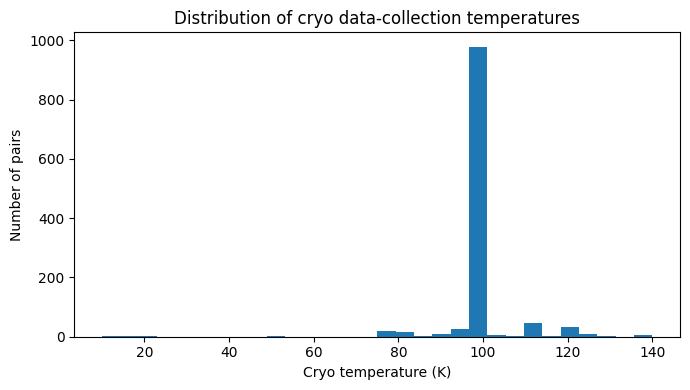

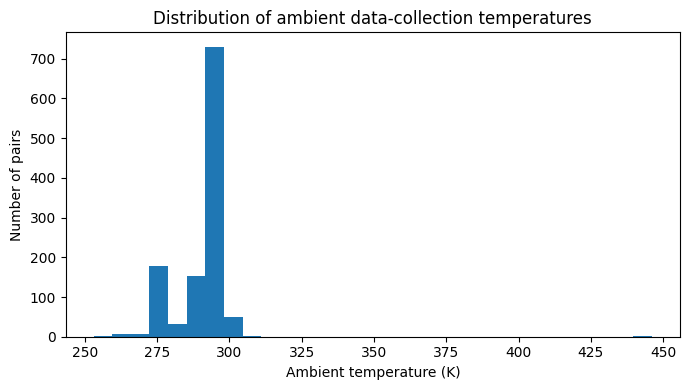

Temperature rule violations:


,count
cryo_not_below_150K,0
ambient_not_above_250K,0


In [5]:
required_temp_cols = ["temp_cryo", "temp_ambient"]
missing_temp_cols = [c for c in required_temp_cols if c not in manifest.columns]

if missing_temp_cols:
    print("Missing temperature columns:", missing_temp_cols)
else:
    display(manifest[required_temp_cols].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(manifest["temp_cryo"].dropna(), bins=30)
    plt.xlabel("Cryo temperature (K)")
    plt.ylabel("Number of pairs")
    plt.title("Distribution of cryo data-collection temperatures")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(manifest["temp_ambient"].dropna(), bins=30)
    plt.xlabel("Ambient temperature (K)")
    plt.ylabel("Number of pairs")
    plt.title("Distribution of ambient data-collection temperatures")
    plt.tight_layout()
    plt.show()

    temp_flags = pd.DataFrame({
        "cryo_not_below_150K": manifest["temp_cryo"] >= 150,
        "ambient_not_above_250K": manifest["temp_ambient"] <= 250,
    })

    print("Temperature rule violations:")
    display(temp_flags.sum().to_frame("count"))

## 4. Check resolution quality and resolution difference

The original mining notebook filtered for structures with resolution better than 2.5 Å. Here I check the final distribution and how different the cryo and ambient resolutions are within each matched pair.

Large resolution differences may make B-factor differences harder to interpret biologically.

,resolution_cryo,resolution_ambient,resolution_diff_abs
count,1162.000000,1162.000000,1162.000000
mean,1.764429,1.965681,0.327359
std,0.396040,0.343024,0.259182
min,0.480000,0.700000,0.000000
25%,1.490500,1.750000,0.100000
50%,1.800000,2.000000,0.289500
75%,2.060000,2.200000,0.487500
max,2.500000,2.500000,1.380000


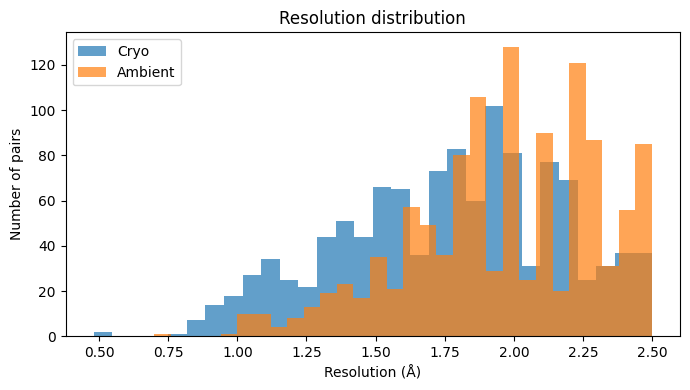

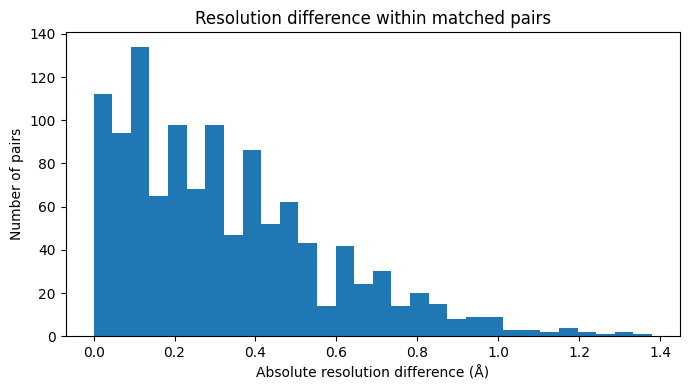

Pairs with resolution difference > 0.75 Å:


,pair_id,uniprot,pdb_cryo,chain_cryo,pdb_ambient,chain_ambient,space_group,cell_a_cryo,cell_b_cryo,cell_c_cryo,cell_a_ambient,cell_b_ambient,cell_c_ambient,max_cell_dev_pct,resolution_cryo,resolution_ambient,temp_cryo,temp_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo,aa_disagreements,labels_path,sequence_path,resolution_diff_abs
29,A0A4P7N8E2_8Z38_8Z28,A0A4P7N8E2,8Z38,A,8Z28,A,P 21 21 21,55.157,59.382,67.246,55.453,61.066,68.072,2.757672,2.170,1.350,100.0,291.15,113,112,1,0,0,labels\A0A4P7N8E2_8Z38_8Z28.npz,sequences\A0A4P7N8E2.fasta,0.820
35,A0A7I9C8Z1_8C3X_9G99,A0A7I9C8Z1,8C3X,A,9G99,A,P 21 21 21,41.210,59.800,90.070,41.577,60.971,91.308,1.920585,0.820,2.150,100.0,293.00,247,214,17,16,201,labels\A0A7I9C8Z1_8C3X_9G99.npz,sequences\A0A7I9C8Z1.fasta,1.330
58,A9CH39_4DJA_6DD6,A9CH39,4DJA,A,6DD6,A,P 21 21 2,98.388,106.786,55.913,99.700,106.800,57.300,2.420593,1.450,2.300,100.0,294.00,512,509,3,0,0,labels\A9CH39_4DJA_6DD6.npz,sequences\A9CH39.fasta,0.850
60,A9JQL9_3ACX_3LGZ,A9JQL9,3ACX,A,3LGZ,B,P 32 2 1,80.628,80.628,90.453,80.840,80.840,91.264,0.888631,1.310,2.410,100.0,298.00,284,279,0,5,1,labels\A9JQL9_3ACX_3LGZ.npz,sequences\A9JQL9.fasta,1.100
135,O31526_2Z8R_2Z8S,O31526,2Z8R,A,2Z8S,A,P 1 21 1,56.897,106.153,101.041,56.617,105.152,100.668,0.942979,1.400,2.500,100.0,277.00,583,583,0,0,0,labels\O31526_2Z8R_2Z8S.npz,sequences\O31526.fasta,1.100
137,O35744_1VF8_1E9L,O35744,1VF8,A,1E9L,A,P 1 21 1,50.611,60.123,60.106,51.340,60.660,60.760,1.419945,1.310,2.500,100.0,290.00,393,352,20,21,330,labels\O35744_1VF8_1E9L.npz,sequences\O35744.fasta,1.190
143,O57385_1MC2_1MG6,O57385,1MC2,A,1MG6,A,C 1 2 1,44.732,59.086,45.308,45.300,59.550,46.130,1.781921,0.850,1.600,100.0,298.00,244,0,122,122,0,labels\O57385_1MC2_1MG6.npz,sequences\O57385.fasta,0.750
164,O92956_1CXQ_1VSH,O92956,1CXQ,A,1VSH,A,P 43 21 2,65.540,65.540,80.120,66.080,66.080,80.960,1.037549,1.020,1.950,95.0,298.00,148,140,5,3,0,labels\O92956_1CXQ_1VSH.npz,sequences\O92956.fasta,0.930
166,P00004_6K9J_6K9I,P00004,6K9J,A,6K9I,A,P 43,56.887,56.887,42.487,58.395,58.395,41.909,2.582413,0.980,1.800,110.0,293.00,104,104,0,0,0,labels\P00004_6K9J_6K9I.npz,sequences\P00004.fasta,0.820
167,P00142_2J8W_1JAF,P00142,2J8W,A,1JAF,A,P 31 2 1,69.630,69.630,123.630,70.180,70.180,126.850,2.538431,1.290,2.500,100.0,298.00,129,128,0,1,0,labels\P00142_2J8W_1JAF.npz,sequences\P00142.fasta,1.210


In [6]:
res_cols = ["resolution_cryo", "resolution_ambient"]
missing_res_cols = [c for c in res_cols if c not in manifest.columns]

if missing_res_cols:
    print("Missing resolution columns:", missing_res_cols)
else:
    manifest["resolution_diff_abs"] = (
        manifest["resolution_cryo"] - manifest["resolution_ambient"]
    ).abs()

    display(manifest[res_cols + ["resolution_diff_abs"]].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(manifest["resolution_cryo"].dropna(), bins=30, alpha=0.7, label="Cryo")
    plt.hist(manifest["resolution_ambient"].dropna(), bins=30, alpha=0.7, label="Ambient")
    plt.xlabel("Resolution (Å)")
    plt.ylabel("Number of pairs")
    plt.title("Resolution distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(manifest["resolution_diff_abs"].dropna(), bins=30)
    plt.xlabel("Absolute resolution difference (Å)")
    plt.ylabel("Number of pairs")
    plt.title("Resolution difference within matched pairs")
    plt.tight_layout()
    plt.show()

    print("Pairs with resolution difference > 0.75 Å:")
    display(manifest.loc[manifest["resolution_diff_abs"] > 0.75].head(20))

## 5. Check unit cell similarity

The first notebook matched structures using same UniProt, same space group, and similar unit cell dimensions. This check summarizes the unit cell deviation.

Because the goal is to compare structures in the same crystal form, pairs with very different unit cells should be removed before modeling.

count    1162.000000
mean        1.176406
std         0.998498
min         0.000000
25%         0.418528
50%         0.955050
75%         1.647296
max         4.939387
Name: max_cell_dev_pct, dtype: float64

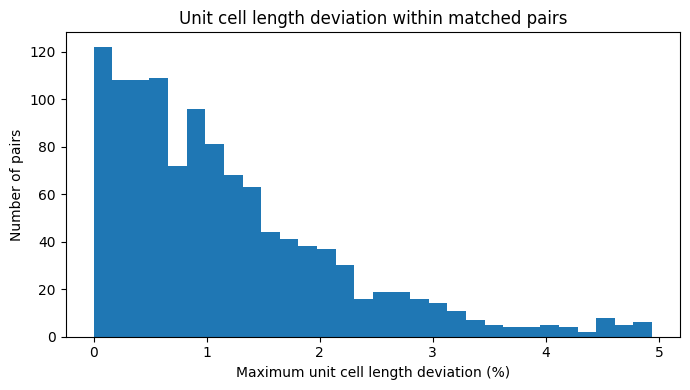

Pairs with max cell deviation > 5%:


,pair_id,uniprot,pdb_cryo,chain_cryo,pdb_ambient,chain_ambient,space_group,cell_a_cryo,cell_b_cryo,cell_c_cryo,cell_a_ambient,cell_b_ambient,cell_c_ambient,max_cell_dev_pct,resolution_cryo,resolution_ambient,temp_cryo,temp_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo,aa_disagreements,labels_path,sequence_path,resolution_diff_abs


In [8]:
if "max_cell_dev_pct" in manifest.columns:
    display(manifest["max_cell_dev_pct"].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(manifest["max_cell_dev_pct"].dropna(), bins=30)
    plt.xlabel("Maximum unit cell length deviation (%)")
    plt.ylabel("Number of pairs")
    plt.title("Unit cell length deviation within matched pairs")
    plt.tight_layout()
    plt.show()

    print("Pairs with max cell deviation > 5%:")
    display(manifest.loc[manifest["max_cell_dev_pct"] > 5].head(20))
else:
    print("No max_cell_dev_pct column found.")

## 6. Check residue-level label availability

The main continuous label is the difference in normalized B-factor between ambient and cryo structures.

This section checks how many residues are modeled in both structures, how many are only modeled in ambient, and how many are only modeled in cryo.

,n_residues,n_modeled_both,n_only_ambient,n_only_cryo
count,1162.000000,1162.000000,1162.000000,1162.000000
mean,264.619621,254.579174,5.197935,4.842513
std,161.796759,159.681032,31.432940,27.273871
min,4.000000,0.000000,0.000000,0.000000
25%,142.000000,137.000000,0.000000,0.000000
50%,244.000000,237.000000,0.000000,0.000000
75%,344.750000,334.000000,2.000000,2.000000
max,1231.000000,1231.000000,553.000000,475.000000


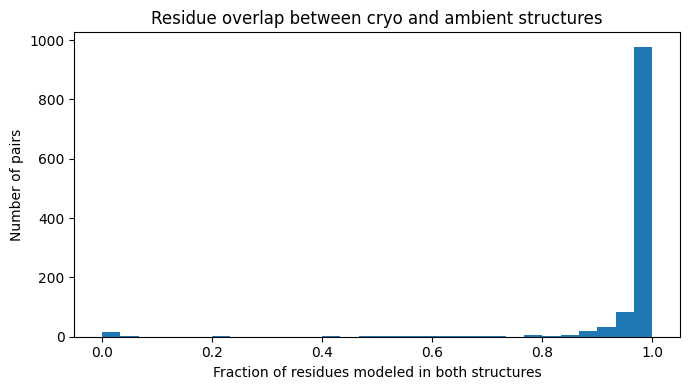

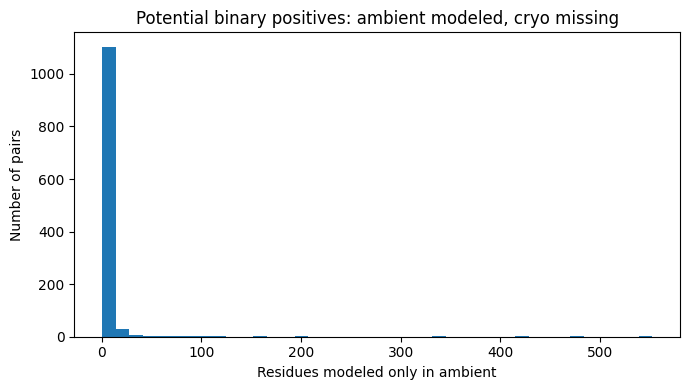

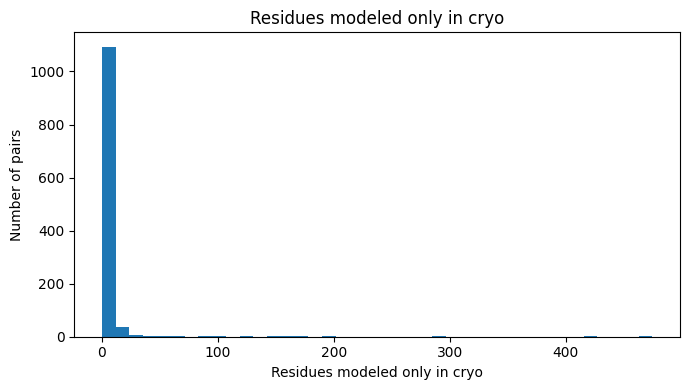

In [10]:
label_count_cols = ["n_residues", "n_modeled_both", "n_only_ambient", "n_only_cryo"]
existing_label_count_cols = [c for c in label_count_cols if c in manifest.columns]

if existing_label_count_cols:
    display(manifest[existing_label_count_cols].describe())

    if {"n_modeled_both", "n_residues"}.issubset(manifest.columns):
        manifest["frac_modeled_both"] = manifest["n_modeled_both"] / manifest["n_residues"].replace(0, np.nan)

        plt.figure(figsize=(7, 4))
        plt.hist(manifest["frac_modeled_both"].dropna(), bins=30)
        plt.xlabel("Fraction of residues modeled in both structures")
        plt.ylabel("Number of pairs")
        plt.title("Residue overlap between cryo and ambient structures")
        plt.tight_layout()
        plt.show()

    if "n_only_ambient" in manifest.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(manifest["n_only_ambient"].dropna(), bins=40)
        plt.xlabel("Residues modeled only in ambient")
        plt.ylabel("Number of pairs")
        plt.title("Potential binary positives: ambient modeled, cryo missing")
        plt.tight_layout()
        plt.show()

    if "n_only_cryo" in manifest.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(manifest["n_only_cryo"].dropna(), bins=40)
        plt.xlabel("Residues modeled only in cryo")
        plt.ylabel("Number of pairs")
        plt.title("Residues modeled only in cryo")
        plt.tight_layout()
        plt.show()
else:
    print("No residue label count columns found.")

## 7. Inspect actual delta B-factor distributions from label files

The manifest gives pair-level summaries, but the `.npz` files contain the actual per-residue labels.

Here I load the label arrays and summarize the distribution of Δ normalized B-factor values across the dataset.

Total valid residue-level delta B labels: 295821
count    295821.000000
mean         -0.001573
std           0.552989
min         -11.923503
25%          -0.232468
50%          -0.002880
75%           0.228421
max           8.886201
dtype: float64


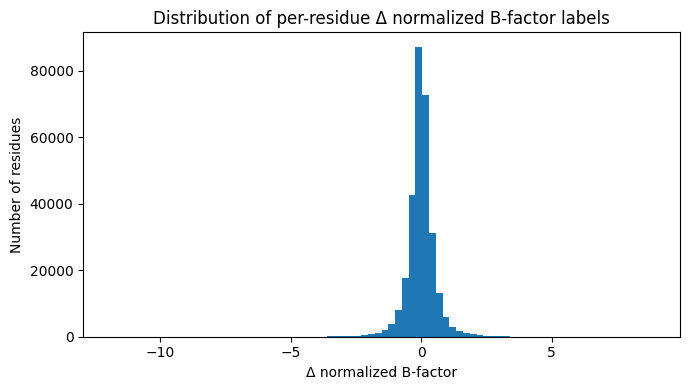

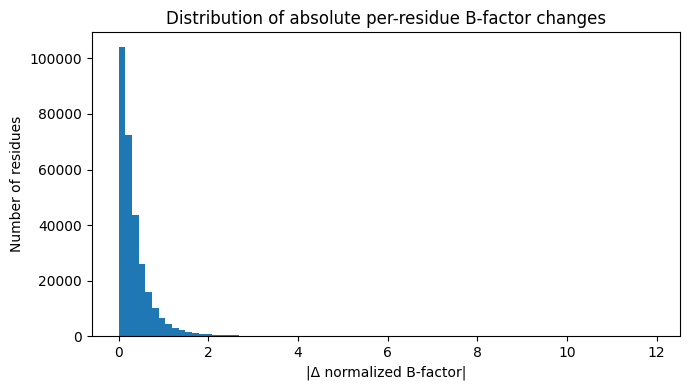

,pair_id,uniprot,n_valid_delta_b,mean_delta_b,median_delta_b,mean_abs_delta_b,max_abs_delta_b
0,A0A075B6C4_7N5P_7N4K,A0A075B6C4,195,-1.111243e-02,-0.002924,0.209235,1.739068
1,A0A086IRG1_9RQ3_9S5B,A0A086IRG1,137,-2.382182e-02,-0.145820,0.459072,2.758522
2,A0A0A1EQY0_8HTY_8IQ7,A0A0A1EQY0,356,-5.987720e-17,-0.013384,0.557220,3.375080
3,A0A0C3QM78_9H06_9H07,A0A0C3QM78,226,1.586458e-01,0.023720,0.369647,2.479414
4,A0A0E1CQ35_9G1M_9G1E,A0A0E1CQ35,137,2.236654e-16,-0.128377,0.485540,2.443745


In [11]:
def resolve_label_path(row):
    """
    Finds the label .npz file for a manifest row.

    The first notebook may store a label_path column.
    If not, this function assumes labels are named by pair_id.
    """
    if "label_path" in row.index and pd.notna(row["label_path"]):
        p = Path(row["label_path"])
        if not p.is_absolute():
            p = DATA_DIR / p
        return p

    return LABEL_DIR / f"{row['pair_id']}.npz"


def load_label_arrays(row):
    label_path = resolve_label_path(row)
    if not label_path.exists():
        raise FileNotFoundError(f"Missing label file: {label_path}")

    data = np.load(label_path, allow_pickle=True)
    return data


# Load all delta_b values where mask is True
all_delta = []
pair_delta_summaries = []

for _, row in manifest.iterrows():
    try:
        lab = load_label_arrays(row)
        delta_b = lab["delta_b"]
        mask = lab["mask"].astype(bool)

        valid_delta = delta_b[mask]
        valid_delta = valid_delta[np.isfinite(valid_delta)]

        if len(valid_delta) > 0:
            all_delta.append(valid_delta)
            pair_delta_summaries.append({
                "pair_id": row["pair_id"],
                "uniprot": row["uniprot"],
                "n_valid_delta_b": len(valid_delta),
                "mean_delta_b": float(np.mean(valid_delta)),
                "median_delta_b": float(np.median(valid_delta)),
                "mean_abs_delta_b": float(np.mean(np.abs(valid_delta))),
                "max_abs_delta_b": float(np.max(np.abs(valid_delta))),
            })

    except Exception as e:
        pair_delta_summaries.append({
            "pair_id": row.get("pair_id", None),
            "uniprot": row.get("uniprot", None),
            "error": str(e),
        })

pair_delta_df = pd.DataFrame(pair_delta_summaries)

if all_delta:
    all_delta = np.concatenate(all_delta)
    print("Total valid residue-level delta B labels:", len(all_delta))
    print(pd.Series(all_delta).describe())

    plt.figure(figsize=(7, 4))
    plt.hist(all_delta, bins=80)
    plt.xlabel("Δ normalized B-factor")
    plt.ylabel("Number of residues")
    plt.title("Distribution of per-residue Δ normalized B-factor labels")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(np.abs(all_delta), bins=80)
    plt.xlabel("|Δ normalized B-factor|")
    plt.ylabel("Number of residues")
    plt.title("Distribution of absolute per-residue B-factor changes")
    plt.tight_layout()
    plt.show()

display(pair_delta_df.head())

## 8. Identify proteins/pairs with the largest B-factor changes

This helps confirm that the label is not completely random. Pairs with large average absolute ΔB may be biologically interesting, but they may also reflect noisy structure matching or refinement differences.

I will inspect these rather than blindly trusting them.

,pair_id,uniprot,n_valid_delta_b,mean_delta_b,median_delta_b,mean_abs_delta_b,max_abs_delta_b
605,P24627_3UK4_3MJN,P24627,6,3.034779e+00,3.171205,3.034779,3.625620
451,P0C6X7_2Z9K_2Q6G,P0C6X7,11,-2.676666e-01,-0.368311,1.304416,2.219826
278,P02400_3N3X_3N2D,P02400,6,-4.366877e-15,0.123832,1.275371,1.820827
1046,Q92692_8X6B_9E6Y,Q92692,95,2.380223e-01,-0.002343,1.208507,6.023245
1108,Q9NZQ7_7NLD_9QSM,Q9NZQ7,102,3.138229e-02,-0.034103,1.131775,3.368027
458,P0DOX5_9BEX_8ZCK,P0DOX5,200,-3.786003e-02,0.062986,1.126738,4.646906
653,P30405_4J5E_8EJX,P30405,121,1.923877e-01,0.267312,1.126607,4.429435
879,Q04837_6RUP_3ULL,Q04837,85,1.764526e-01,0.106989,1.096012,2.974968
529,P16094_6LOV_1F8Q,P16094,223,5.308978e-03,-0.147810,1.067650,4.042020
137,O35744_1VF8_1E9L,O35744,352,-1.967512e-02,0.003420,1.043147,5.423669


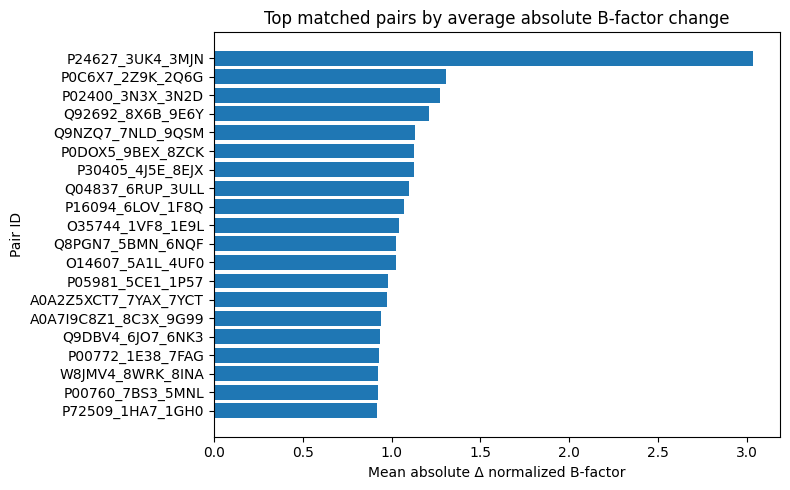

In [13]:
if "mean_abs_delta_b" in pair_delta_df.columns:
    top_delta_pairs = pair_delta_df.sort_values("mean_abs_delta_b", ascending=False).head(20)
    display(top_delta_pairs)

    plt.figure(figsize=(8, 5))
    plt.barh(
        top_delta_pairs["pair_id"].astype(str)[::-1],
        top_delta_pairs["mean_abs_delta_b"][::-1]
    )
    plt.xlabel("Mean absolute Δ normalized B-factor")
    plt.ylabel("Pair ID")
    plt.title("Top matched pairs by average absolute B-factor change")
    plt.tight_layout()
    plt.show()
else:
    print("No mean_abs_delta_b column found.")

## 9. Check whether the binary missing-residue label is usable

The original biological motivation includes residues that are ordered/modelled at ambient temperature but missing/disordered under cryo conditions.

This is biologically clean, but it may be too sparse for the main supervised task. This section counts how many possible positive binary labels exist.

In [14]:
if "n_only_ambient" in manifest.columns:
    total_only_ambient = manifest["n_only_ambient"].sum()
    total_residues = manifest["n_residues"].sum() if "n_residues" in manifest.columns else np.nan

    print("Total residues modeled only in ambient:", total_only_ambient)
    print("Total residues in manifest:", total_residues)

    if pd.notna(total_residues) and total_residues > 0:
        print("Approximate percent only ambient:", 100 * total_only_ambient / total_residues)

    print("\nPairs with at least one ambient-only residue:")
    print((manifest["n_only_ambient"] > 0).sum())

    print("\nPairs with at least 5 ambient-only residues:")
    print((manifest["n_only_ambient"] >= 5).sum())

    print("\nPairs with at least 10 ambient-only residues:")
    print((manifest["n_only_ambient"] >= 10).sum())

    display(
        manifest.sort_values("n_only_ambient", ascending=False)
        .head(25)
        [["pair_id", "uniprot", "pdb_cryo", "pdb_ambient", "n_residues", "n_modeled_both", "n_only_ambient", "n_only_cryo"]]
    )
else:
    print("n_only_ambient column not found.")

Total residues modeled only in ambient: 6040
Total residues in manifest: 307488
Approximate percent only ambient: 1.9643042980539078

Pairs with at least one ambient-only residue:
472

Pairs with at least 5 ambient-only residues:
163

Pairs with at least 10 ambient-only residues:
86


,pair_id,uniprot,pdb_cryo,pdb_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo
1112,Q9I194_4M1J_5UBL,Q9I194,4M1J,5UBL,718,165,553,0
670,P31723_2RI9_1KKT,P31723,2RI9,1KKT,950,0,475,475
615,P24630_3FQA_4GSA,P24630,3FQA,4GSA,853,0,427,426
614,P24627_3UK4_3MJN,P24627,3UK4,3MJN,341,6,335,0
253,P01011_6HGM_1AS4,P01011,6HGM,1AS4,367,0,334,33
586,P22102_4ZZ2_1ZLY,P22102,4ZZ2,1ZLY,400,0,200,200
693,P35804_1S0W_1JTG,P35804,1S0W,1JTG,330,0,165,165
374,P07550_5D5A_9RKF,P07550,5D5A,9RKF,602,282,160,160
459,P0C918_2CAL_2CAK,P0C918,2CAL,2CAK,307,0,154,153
143,O57385_1MC2_1MG6,O57385,1MC2,1MG6,244,0,122,122


## 10. Check amino-acid disagreement / construct mismatch

A key possible source of noise is comparing structures that map to the same UniProt ID but do not actually represent the same construct or sequence region.

If the first notebook recorded amino-acid disagreements, I use that column to flag potentially unreliable pairs.

Using disagreement column: aa_disagreements


count    1162.000000
mean       10.513769
std        45.531527
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       450.000000
Name: aa_disagreements, dtype: float64

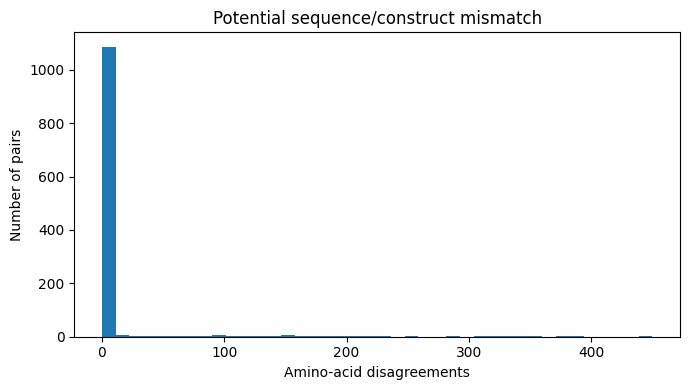

Pairs with > 5 amino-acid disagreements:


,pair_id,uniprot,pdb_cryo,chain_cryo,pdb_ambient,chain_ambient,space_group,cell_a_cryo,cell_b_cryo,cell_c_cryo,cell_a_ambient,cell_b_ambient,cell_c_ambient,max_cell_dev_pct,resolution_cryo,resolution_ambient,temp_cryo,temp_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo,aa_disagreements,labels_path,sequence_path,resolution_diff_abs,max_cell_angle_dev_deg,frac_modeled_both
1010,Q80J95_3UQS_3SFG,Q80J95,3UQS,A,3SFG,A,C 1 2 1,120.670,196.330,109.150,120.794,195.972,109.335,0.182346,2.000,2.209,100.0,277.00,485,473,7,5,450,labels\Q80J95_3UQS_3SFG.npz,sequences\Q80J95.fasta,0.209,NaN,0.975258
1046,Q8PGN7_5BMN_6NQF,Q8PGN7,5BMN,A,6NQF,A,P 21 21 21,43.980,55.180,174.700,44.460,55.490,174.710,1.079622,1.270,1.900,100.0,298.00,470,424,23,23,392,labels\Q8PGN7_5BMN_6NQF.npz,sequences\Q8PGN7.fasta,0.630,NaN,0.902128
1160,W8JMV4_8WRK_8INA,W8JMV4,8WRK,A,8INA,A,P 21 21 21,45.673,52.645,200.340,45.741,52.667,202.111,0.876251,2.030,1.860,100.0,291.15,462,403,28,31,377,labels\W8JMV4_8WRK_8INA.npz,sequences\W8JMV4.fasta,0.170,NaN,0.872294
982,Q6B856_9F8G_8CL9,Q6B856,9F8G,B,8CL9,B,P 1 21 1,73.460,91.115,82.684,73.470,91.190,82.700,0.082246,2.200,2.500,100.0,293.00,441,416,15,10,355,labels\Q6B856_9F8G_8CL9.npz,sequences\Q6B856.fasta,0.300,NaN,0.943311
316,P03472_6HG0_1BJI,P03472,6HG0,A,1BJI,A,I 4 3 2,181.200,181.200,181.200,182.800,182.800,182.800,0.875274,1.300,2.000,100.0,300.00,389,384,1,4,342,labels\P03472_6HG0_1BJI.npz,sequences\P03472.fasta,0.700,NaN,0.987147
947,Q46393_5H8Z_3ENI,Q46393,5H8Z,A,3ENI,A,P 43 3 2,168.358,168.358,168.358,169.100,169.100,169.100,0.438794,1.800,2.200,100.0,298.00,359,357,1,1,334,labels\Q46393_5H8Z_3ENI.npz,sequences\Q46393.fasta,0.400,NaN,0.994429
137,O35744_1VF8_1E9L,O35744,1VF8,A,1E9L,A,P 1 21 1,50.611,60.123,60.106,51.340,60.660,60.760,1.419945,1.310,2.500,100.0,290.00,393,352,20,21,330,labels\O35744_1VF8_1E9L.npz,sequences\O35744.fasta,1.190,NaN,0.895674
124,O14607_5A1L_4UF0,O14607,5A1L,A,4UF0,B,P 21 21 21,90.711,110.500,119.460,90.494,110.458,119.230,0.239221,2.000,1.780,100.0,287.00,545,337,102,106,316,labels\O14607_5A1L_4UF0.npz,sequences\O14607.fasta,0.220,NaN,0.618349
641,P28482_8AO6_6NBS,P28482,8AO6,A,6NBS,A,P 1 21 1,48.894,71.026,60.215,48.895,71.242,60.167,0.303192,1.811,1.900,100.0,446.15,346,332,10,4,312,labels\P28482_8AO6_6NBS.npz,sequences\P28482.fasta,0.089,NaN,0.959538
736,P44801_1TA4_1NX6,P44801,1TA4,A,1NX6,A,P 21 21 2,113.769,54.843,57.487,113.748,54.853,57.691,0.353608,2.280,2.150,100.0,298.00,358,353,3,2,289,labels\P44801_1TA4_1NX6.npz,sequences\P44801.fasta,0.130,NaN,0.986034


In [15]:
possible_disagreement_cols = [
    "aa_disagreements",
    "n_aa_disagreements",
    "sequence_disagreements",
    "n_sequence_disagreements"
]

disagreement_col = None
for c in possible_disagreement_cols:
    if c in manifest.columns:
        disagreement_col = c
        break

if disagreement_col is not None:
    print("Using disagreement column:", disagreement_col)
    display(manifest[disagreement_col].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(manifest[disagreement_col].dropna(), bins=40)
    plt.xlabel("Amino-acid disagreements")
    plt.ylabel("Number of pairs")
    plt.title("Potential sequence/construct mismatch")
    plt.tight_layout()
    plt.show()

    print("Pairs with > 5 amino-acid disagreements:")
    display(
        manifest.loc[manifest[disagreement_col] > 5]
        .sort_values(disagreement_col, ascending=False)
        .head(20)
    )
else:
    print("No amino-acid disagreement column found.")

## 11. Define filtering rules

These filters are intentionally conservative. The goal is not to create a perfect dataset, but to remove obviously problematic pairs before training.

Current filtering logic:

- Keep pairs with cryo temperature < 150 K.
- Keep pairs with ambient temperature > 250 K.
- Keep pairs with both structures at resolution ≤ 2.5 Å.
- Keep pairs with resolution difference ≤ 0.75 Å.
- Keep pairs with max unit cell length deviation ≤ 5%.
- If angle data are available, keep pairs with max angle deviation ≤ 2 degrees.
- Keep pairs where at least 60% of residues are modeled in both structures.
- If amino-acid disagreements are available, remove pairs with more than 5 disagreements.

These thresholds can be adjusted after looking at the QC plots.

In [16]:
filtered = manifest.copy()

# Default pass column
filtered["passes_qc"] = True
filter_reasons = {idx: [] for idx in filtered.index}

def fail_where(condition, reason):
    idxs = filtered.index[condition.fillna(False) if hasattr(condition, "fillna") else condition]
    filtered.loc[idxs, "passes_qc"] = False
    for idx in idxs:
        filter_reasons[idx].append(reason)

# Temperature rules
if "temp_cryo" in filtered.columns:
    fail_where(filtered["temp_cryo"] >= 150, "cryo_temp_not_below_150K")

if "temp_ambient" in filtered.columns:
    fail_where(filtered["temp_ambient"] <= 250, "ambient_temp_not_above_250K")

# Resolution rules
if "resolution_cryo" in filtered.columns:
    fail_where(filtered["resolution_cryo"] > 2.5, "cryo_resolution_worse_than_2.5A")

if "resolution_ambient" in filtered.columns:
    fail_where(filtered["resolution_ambient"] > 2.5, "ambient_resolution_worse_than_2.5A")

if "resolution_diff_abs" in filtered.columns:
    fail_where(filtered["resolution_diff_abs"] > 0.75, "resolution_difference_above_0.75A")

# Unit cell rules
if "max_cell_dev_pct" in filtered.columns:
    fail_where(filtered["max_cell_dev_pct"] > 5, "cell_length_deviation_above_5pct")

if "max_cell_angle_dev_deg" in filtered.columns and filtered["max_cell_angle_dev_deg"].notna().any():
    fail_where(filtered["max_cell_angle_dev_deg"] > 2, "cell_angle_deviation_above_2deg")

# Residue overlap rule
if "frac_modeled_both" in filtered.columns:
    fail_where(filtered["frac_modeled_both"] < 0.60, "less_than_60pct_residues_modeled_both")

# Sequence disagreement rule
if disagreement_col is not None:
    fail_where(filtered[disagreement_col] > 5, "more_than_5_aa_disagreements")

filtered["qc_filter_reasons"] = [
    ";".join(filter_reasons[idx]) if filter_reasons[idx] else "pass"
    for idx in filtered.index
]

print("Before filtering:", len(filtered))
print("After filtering:", filtered["passes_qc"].sum())
print("Removed:", (~filtered["passes_qc"]).sum())

display(filtered["qc_filter_reasons"].value_counts().head(20))

filtered_manifest = filtered.loc[filtered["passes_qc"]].copy().reset_index(drop=True)
filtered_manifest.head()

Before filtering: 1162
After filtering: 970
Removed: 192


qc_filter_reasons
pass                                                                       970
more_than_5_aa_disagreements                                                80
resolution_difference_above_0.75A                                           72
less_than_60pct_residues_modeled_both                                       20
resolution_difference_above_0.75A;more_than_5_aa_disagreements               9
less_than_60pct_residues_modeled_both;more_than_5_aa_disagreements           8
resolution_difference_above_0.75A;less_than_60pct_residues_modeled_both      3
Name: count, dtype: int64

,pair_id,uniprot,pdb_cryo,chain_cryo,pdb_ambient,chain_ambient,space_group,cell_a_cryo,cell_b_cryo,cell_c_cryo,cell_a_ambient,cell_b_ambient,cell_c_ambient,max_cell_dev_pct,resolution_cryo,resolution_ambient,temp_cryo,temp_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo,aa_disagreements,labels_path,sequence_path,resolution_diff_abs,max_cell_angle_dev_deg,frac_modeled_both,passes_qc,qc_filter_reasons
0,A0A075B6C4_7N5P_7N4K,A0A075B6C4,7N5P,D,7N4K,D,P 1 21 1,54.334,72.056,107.671,54.140,72.530,107.720,0.653523,2.09,1.85,100.0,277.00,196,195,1,0,0,labels\A0A075B6C4_7N5P_7N4K.npz,sequences\A0A075B6C4.fasta,0.24,NaN,0.994898,True,pass
1,A0A086IRG1_9RQ3_9S5B,A0A086IRG1,9RQ3,A,9S5B,A,P 21 21 2,68.278,89.802,44.974,69.280,90.830,45.260,1.446305,1.22,1.50,100.0,296.00,138,137,1,0,0,labels\A0A086IRG1_9RQ3_9S5B.npz,sequences\A0A086IRG1.fasta,0.28,NaN,0.992754,True,pass
2,A0A0A1EQY0_8HTY_8IQ7,A0A0A1EQY0,8HTY,A,8IQ7,A,P 1,54.132,68.959,109.792,54.668,69.509,110.800,0.980464,1.40,2.10,100.0,298.00,356,356,0,0,0,labels\A0A0A1EQY0_8HTY_8IQ7.npz,sequences\A0A0A1EQY0.fasta,0.70,NaN,1.000000,True,pass
3,A0A0C3QM78_9H06_9H07,A0A0C3QM78,9H06,A,9H07,A,P 43 21 2,59.971,59.971,231.864,59.959,59.959,231.749,0.049598,1.86,2.41,100.0,293.00,235,226,0,9,0,labels\A0A0C3QM78_9H06_9H07.npz,sequences\A0A0C3QM78.fasta,0.55,NaN,0.961702,True,pass
4,A0A0E1CQ35_9G1M_9G1E,A0A0E1CQ35,9G1M,A,9G1E,A,P 21 21 2,68.150,89.792,44.998,69.350,90.880,45.300,1.730353,1.18,1.40,100.0,296.15,137,137,0,0,0,labels\A0A0E1CQ35_9G1M_9G1E.npz,sequences\A0A0E1CQ35.fasta,0.22,NaN,1.000000,True,pass


## 12. Save cleaned manifest

This cleaned manifest will be used for ESM embedding generation and model training.

The unfiltered manifest is still preserved, so filtering choices can be revisited later.

In [17]:
FILTERED_MANIFEST_PATH = DATA_DIR / "manifest_qc_filtered.csv"

filtered_manifest.to_csv(FILTERED_MANIFEST_PATH, index=False)

print(f"Wrote cleaned manifest with {len(filtered_manifest)} rows to:")
print(FILTERED_MANIFEST_PATH)

Wrote cleaned manifest with 970 rows to:
data\manifest_qc_filtered.csv


## 13. Load FASTA sequences

Even if each UniProt ID is unique, homologous proteins can still appear in both train and validation sets.

To reduce leakage, I will build simple sequence-similarity clusters. Later, model splits should be done by cluster, not just by UniProt ID.

This is a lightweight approximation using k-mer Jaccard similarity. It is not a perfect substitute for MMseqs2/CD-HIT, but it is useful for a class-project-level leakage check.

Sequences loaded: 970 / 970


count     970.000000
mean      273.525773
std       167.499524
min         5.000000
25%       146.000000
50%       255.500000
75%       357.000000
max      1231.000000
Name: seq_len, dtype: float64

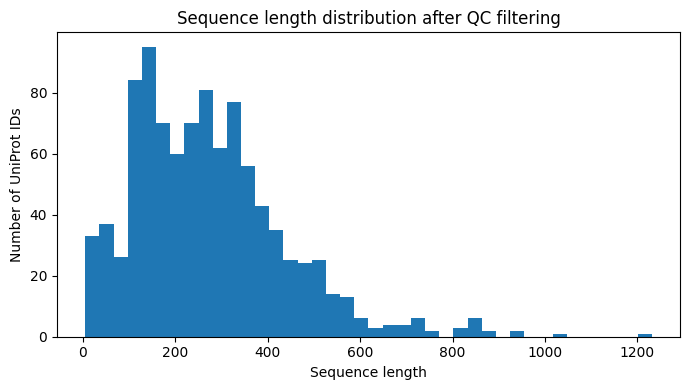

,uniprot,sequence,seq_len
0,A0A075B6C4,KTTQPDSMESTEGETVHLPCSHATISGNEYIYWYRQVPLQGPEYVT...,199
1,A0A086IRG1,MLSGLNHLTLAVSQLAPSVAFYQQLLGMTLHARWDSGAYLSCGDLW...,145
2,A0A0A1EQY0,MKIVLVLYDAGKHAADEEKLYGCTENKLGIANWLKDQGHELITTSD...,364
3,A0A0C3QM78,GSGSDQSPKPLATRDEKITYLRKIIGDKGSDAWDVAWQEGVTPWDQ...,252
4,A0A0E1CQ35,MLSGLNHLTLAVSQLAPSVAFYQQLLGMTLHARWDSGAYLSCGDLW...,145


In [18]:
def read_fasta(path):
    seq_lines = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(">"):
                continue
            seq_lines.append(line)
    return "".join(seq_lines)


def get_sequence_for_uniprot(uniprot):
    fasta_path = SEQ_DIR / f"{uniprot}.fasta"
    if not fasta_path.exists():
        return None
    return read_fasta(fasta_path)


unique_uniprots = sorted(filtered_manifest["uniprot"].dropna().unique())

seq_rows = []
for u in unique_uniprots:
    seq = get_sequence_for_uniprot(u)
    seq_rows.append({
        "uniprot": u,
        "sequence": seq,
        "seq_len": len(seq) if seq is not None else np.nan
    })

seq_df = pd.DataFrame(seq_rows)

print("Sequences loaded:", seq_df["sequence"].notna().sum(), "/", len(seq_df))
display(seq_df["seq_len"].describe())

plt.figure(figsize=(7, 4))
plt.hist(seq_df["seq_len"].dropna(), bins=40)
plt.xlabel("Sequence length")
plt.ylabel("Number of UniProt IDs")
plt.title("Sequence length distribution after QC filtering")
plt.tight_layout()
plt.show()

seq_df.head()

## 14. Build approximate sequence-similarity clusters

This section groups proteins with similar sequence composition using 3-mer Jaccard similarity.

Important note: this is a conservative leakage-control check, not a formal evolutionary homology analysis. For a stronger version, I would use MMseqs2 or CD-HIT outside Python.

In [22]:
def kmers(seq, k=3):
    if seq is None or len(seq) < k:
        return set()
    return {seq[i:i+k] for i in range(len(seq) - k + 1)}


def jaccard(a, b):
    if not a or not b:
        return 0.0
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0


# Threshold can be adjusted.
# Higher = fewer clusters merged.
# Lower = more conservative leakage prevention.
KMER_K = 3
JACCARD_THRESHOLD = 0.50

seq_df = seq_df.dropna(subset=["sequence"]).reset_index(drop=True)
seq_df["kmer_set"] = seq_df["sequence"].apply(lambda s: kmers(s, k=KMER_K))

n = len(seq_df)
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

# Pairwise comparison is okay for ~1000 proteins.
# If this gets slow, increase the threshold or switch to MMseqs2/CD-HIT.
for i in range(n):
    if i % 100 == 0:
        print(f"Comparing sequence {i}/{n}")
    for j in range(i + 1, n):
        sim = jaccard(seq_df.loc[i, "kmer_set"], seq_df.loc[j, "kmer_set"])
        if sim >= JACCARD_THRESHOLD:
            union(i, j)

seq_df["raw_cluster"] = [find(i) for i in range(n)]

# Convert raw cluster ids to clean numbered cluster ids
cluster_map = {
    raw: f"cluster_{idx:04d}"
    for idx, raw in enumerate(sorted(seq_df["raw_cluster"].unique()))
}

seq_df["seq_cluster"] = seq_df["raw_cluster"].map(cluster_map)

cluster_sizes = seq_df["seq_cluster"].value_counts()

print("Number of UniProt sequences:", len(seq_df))
print("Number of approximate sequence clusters:", seq_df["seq_cluster"].nunique())
print("Largest clusters:")
display(cluster_sizes.head(20).to_frame("n_uniprots"))

seq_df[["uniprot", "seq_len", "seq_cluster"]].head()

Comparing sequence 0/970
Comparing sequence 100/970
Comparing sequence 200/970
Comparing sequence 300/970
Comparing sequence 400/970
Comparing sequence 500/970
Comparing sequence 600/970
Comparing sequence 700/970
Comparing sequence 800/970
Comparing sequence 900/970
Number of UniProt sequences: 970
Number of approximate sequence clusters: 909
Largest clusters:


,n_uniprots
seq_cluster,
cluster_0251,5
cluster_0636,5
cluster_0001,3
cluster_0071,3
cluster_0298,3
cluster_0639,3
cluster_0815,3
cluster_0000,2
cluster_0004,2


,uniprot,seq_len,seq_cluster
0,A0A075B6C4,199,cluster_0000
1,A0A086IRG1,145,cluster_0001
2,A0A0A1EQY0,364,cluster_0002
3,A0A0C3QM78,252,cluster_0003
4,A0A0E1CQ35,145,cluster_0001


## 15. Attach sequence clusters to the filtered manifest

After this step, every pair has a `seq_cluster` column.

Later, train/validation/test splitting should use `seq_cluster`, not just `uniprot`, to reduce homolog leakage.

In [23]:
cluster_lookup = seq_df[["uniprot", "seq_cluster", "seq_len"]].drop_duplicates()

filtered_manifest_clustered = filtered_manifest.merge(
    cluster_lookup,
    on="uniprot",
    how="left"
)

print("Rows missing sequence cluster:", filtered_manifest_clustered["seq_cluster"].isna().sum())

display(filtered_manifest_clustered.head())

CLUSTERED_MANIFEST_PATH = DATA_DIR / "manifest_qc_filtered_clustered.csv"
filtered_manifest_clustered.to_csv(CLUSTERED_MANIFEST_PATH, index=False)

print(f"Wrote clustered filtered manifest to:")
print(CLUSTERED_MANIFEST_PATH)

Rows missing sequence cluster: 0


,pair_id,uniprot,pdb_cryo,chain_cryo,pdb_ambient,chain_ambient,space_group,cell_a_cryo,cell_b_cryo,cell_c_cryo,cell_a_ambient,cell_b_ambient,cell_c_ambient,max_cell_dev_pct,resolution_cryo,resolution_ambient,temp_cryo,temp_ambient,n_residues,n_modeled_both,n_only_ambient,n_only_cryo,aa_disagreements,labels_path,sequence_path,resolution_diff_abs,max_cell_angle_dev_deg,frac_modeled_both,passes_qc,qc_filter_reasons,seq_cluster,seq_len
0,A0A075B6C4_7N5P_7N4K,A0A075B6C4,7N5P,D,7N4K,D,P 1 21 1,54.334,72.056,107.671,54.140,72.530,107.720,0.653523,2.09,1.85,100.0,277.00,196,195,1,0,0,labels\A0A075B6C4_7N5P_7N4K.npz,sequences\A0A075B6C4.fasta,0.24,NaN,0.994898,True,pass,cluster_0000,199
1,A0A086IRG1_9RQ3_9S5B,A0A086IRG1,9RQ3,A,9S5B,A,P 21 21 2,68.278,89.802,44.974,69.280,90.830,45.260,1.446305,1.22,1.50,100.0,296.00,138,137,1,0,0,labels\A0A086IRG1_9RQ3_9S5B.npz,sequences\A0A086IRG1.fasta,0.28,NaN,0.992754,True,pass,cluster_0001,145
2,A0A0A1EQY0_8HTY_8IQ7,A0A0A1EQY0,8HTY,A,8IQ7,A,P 1,54.132,68.959,109.792,54.668,69.509,110.800,0.980464,1.40,2.10,100.0,298.00,356,356,0,0,0,labels\A0A0A1EQY0_8HTY_8IQ7.npz,sequences\A0A0A1EQY0.fasta,0.70,NaN,1.000000,True,pass,cluster_0002,364
3,A0A0C3QM78_9H06_9H07,A0A0C3QM78,9H06,A,9H07,A,P 43 21 2,59.971,59.971,231.864,59.959,59.959,231.749,0.049598,1.86,2.41,100.0,293.00,235,226,0,9,0,labels\A0A0C3QM78_9H06_9H07.npz,sequences\A0A0C3QM78.fasta,0.55,NaN,0.961702,True,pass,cluster_0003,252
4,A0A0E1CQ35_9G1M_9G1E,A0A0E1CQ35,9G1M,A,9G1E,A,P 21 21 2,68.150,89.792,44.998,69.350,90.880,45.300,1.730353,1.18,1.40,100.0,296.15,137,137,0,0,0,labels\A0A0E1CQ35_9G1M_9G1E.npz,sequences\A0A0E1CQ35.fasta,0.22,NaN,1.000000,True,pass,cluster_0001,145


Wrote clustered filtered manifest to:
data\manifest_qc_filtered_clustered.csv


In [ ]:
# ------------------------------------------------------------
# Extra QC filter 1:
# Remove tiny fragments and extreme/non-ambient temperature pairs
# ------------------------------------------------------------

filtered_manifest_clustered = filtered_manifest_clustered.copy()

print("Before extra QC filter 1:", filtered_manifest_clustered.shape)

# Recommended thresholds
MIN_SEQ_LEN = 50
MIN_MODELED_BOTH = 50
MAX_AMBIENT_TEMP = 320  # K; removes heated structures that are not really ambient/room-temp

extra_qc_mask = (
    (filtered_manifest_clustered["seq_len"] >= MIN_SEQ_LEN) &
    (filtered_manifest_clustered["n_modeled_both"] >= MIN_MODELED_BOTH) &
    (filtered_manifest_clustered["temp_ambient"] <= MAX_AMBIENT_TEMP)
)

removed_extra_qc = filtered_manifest_clustered.loc[~extra_qc_mask].copy()

print("Rows removed by extra QC filter 1:", len(removed_extra_qc))
print("Rows kept after extra QC filter 1:", extra_qc_mask.sum())

if len(removed_extra_qc) > 0:
    display(
        removed_extra_qc[
            [
                "pair_id", "uniprot", "pdb_cryo", "pdb_ambient",
                "seq_len", "n_modeled_both", "temp_cryo", "temp_ambient"
            ]
        ].head(20)
    )

filtered_manifest_clustered = filtered_manifest_clustered.loc[extra_qc_mask].reset_index(drop=True)

print("After extra QC filter 1:", filtered_manifest_clustered.shape)

Before extra QC filter 1: (970, 33)
Rows removed by extra QC filter 1: 55
Rows kept after extra QC filter 1: 915


,pair_id,uniprot,pdb_cryo,pdb_ambient,seq_len,n_modeled_both,temp_cryo,temp_ambient
74,D0VWR3_8GN2_5WS5,D0VWR3,8GN2,5WS5,30,28,100.00,293.00
75,D0VWR4_8GN2_5WS5,D0VWR4,8GN2,5WS5,40,38,100.00,293.00
112,O13024_5K3Y_2BFY,O13024,5K3Y,2BFY,43,35,100.00,287.00
135,O60673_6BC8_6BCD,O60673,6BC8,6BCD,28,25,77.15,289.15
148,O89752_7N5P_7N4K,O89752,7N5P,7N4K,10,10,100.00,277.00
153,P00273_1DHG_1DCD,P00273,1DHG,1DCD,36,36,110.00,277.00
169,P00430_3ABL_5X1F,P00430,3ABL,5X1F,47,46,100.00,277.00
219,P01094_1DPJ_1DP5,P01094,1DPJ,1DP5,68,29,100.00,298.00
222,P01308_3E7Z_3W7Z,P01308,3E7Z,3W7Z,30,29,100.00,293.00
223,P01317_6OR0_6QRK,P01317,6OR0,6QRK,30,29,100.00,293.00


After extra QC filter 1: (915, 33)


In [29]:
# ------------------------------------------------------------
# Extra QC filter 2:
# Remove duplicate cryo/ambient PDB-pair keys
# ------------------------------------------------------------

filtered_manifest_clustered = filtered_manifest_clustered.copy()

print("Before extra QC filter 2:", filtered_manifest_clustered.shape)

# Create a structure-pair key.
# Sorting makes A_B and B_A equivalent just in case order ever flips.
filtered_manifest_clustered["pdb_pair_key"] = filtered_manifest_clustered.apply(
    lambda row: "_".join(sorted([str(row["pdb_cryo"]).upper(), str(row["pdb_ambient"]).upper()])),
    axis=1
)

# Check duplicate PDB-pair keys
dup_counts = filtered_manifest_clustered["pdb_pair_key"].value_counts()
duplicate_keys = dup_counts[dup_counts > 1]

print("Number of duplicated PDB-pair keys:", len(duplicate_keys))
print("Rows involved in duplicated PDB-pair keys:", filtered_manifest_clustered["pdb_pair_key"].isin(duplicate_keys.index).sum())

if len(duplicate_keys) > 0:
    duplicated_rows = (
        filtered_manifest_clustered[
            filtered_manifest_clustered["pdb_pair_key"].isin(duplicate_keys.index)
        ]
        .sort_values(["pdb_pair_key", "n_modeled_both"], ascending=[True, False])
    )

    print("Example duplicated PDB-pair rows:")
    display(
        duplicated_rows[
            [
                "pdb_pair_key", "pair_id", "uniprot", "seq_cluster",
                "pdb_cryo", "pdb_ambient", "n_modeled_both",
                "resolution_cryo", "resolution_ambient"
            ]
        ].head(30)
    )

# Keep one row per exact PDB-pair key.
# I recommend keeping the row with the most modeled residues.
filtered_manifest_clustered = (
    filtered_manifest_clustered
    .sort_values("n_modeled_both", ascending=False)
    .drop_duplicates(subset=["pdb_pair_key"], keep="first")
    .reset_index(drop=True)
)

print("After removing duplicate PDB-pair keys:", filtered_manifest_clustered.shape)

# Quick sanity check
remaining_duplicates = filtered_manifest_clustered["pdb_pair_key"].duplicated().sum()
print("Remaining duplicated PDB-pair keys:", remaining_duplicates)

Before extra QC filter 2: (915, 33)
Number of duplicated PDB-pair keys: 40
Rows involved in duplicated PDB-pair keys: 117
Example duplicated PDB-pair rows:


,pdb_pair_key,pair_id,uniprot,seq_cluster,pdb_cryo,pdb_ambient,n_modeled_both,resolution_cryo,resolution_ambient
220,1C08_1J1X,P01823_1J1X_1C08,P01823,cluster_0224,1J1X,1C08,114,1.80,2.30
217,1C08_1J1X,P01642_1J1X_1C08,P01642,cluster_0221,1J1X,1C08,107,1.80,2.30
631,1C1Y_3KUC,P62834_3KUC_1C1Y,P62834,cluster_0642,3KUC,1C1Y,167,1.92,1.90
249,1C1Y_3KUC,P04049_3KUC_1C1Y,P04049,cluster_0256,3KUC,1C1Y,76,1.92,1.90
215,1D5Z_1D6E,P01552_1D5Z_1D6E,P01552,cluster_0219,1D5Z,1D6E,225,2.00,2.45
224,1D5Z_1D6E,P01911_1D5Z_1D6E,P01911,cluster_0228,1D5Z,1D6E,179,2.00,2.45
223,1D5Z_1D6E,P01903_1D5Z_1D6E,P01903,cluster_0227,1D5Z,1D6E,177,2.00,2.45
758,1DIO_1IWB,Q59470_1IWB_1DIO,Q59470,cluster_0766,1IWB,1DIO,551,1.85,2.20
759,1DIO_1IWB,Q59471_1IWB_1DIO,Q59471,cluster_0767,1IWB,1DIO,178,1.85,2.20
760,1DIO_1IWB,Q59472_1IWB_1DIO,Q59472,cluster_0768,1IWB,1DIO,137,1.85,2.20


After removing duplicate PDB-pair keys: (838, 34)
Remaining duplicated PDB-pair keys: 0


## 16. Create cluster-level train/validation/test split

This split prevents the same UniProt from appearing across splits and also reduces the chance that close homologs appear across splits.

AdoMetDC is still excluded from this training dataset and will be kept as the independent biological case study.

In [30]:
RANDOM_SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

rng = random.Random(RANDOM_SEED)

clusters = sorted(filtered_manifest_clustered["seq_cluster"].dropna().unique())
rng.shuffle(clusters)

n_clusters = len(clusters)
n_train = int(TRAIN_FRAC * n_clusters)
n_val = int(VAL_FRAC * n_clusters)

train_clusters = set(clusters[:n_train])
val_clusters = set(clusters[n_train:n_train + n_val])
test_clusters = set(clusters[n_train + n_val:])

def assign_split(cluster):
    if cluster in train_clusters:
        return "train"
    elif cluster in val_clusters:
        return "val"
    elif cluster in test_clusters:
        return "test"
    else:
        return "unassigned"

filtered_manifest_clustered["split"] = filtered_manifest_clustered["seq_cluster"].apply(assign_split)

display(filtered_manifest_clustered["split"].value_counts().to_frame("n_pairs"))

split_summary = (
    filtered_manifest_clustered
    .groupby("split")
    .agg(
        n_pairs=("pair_id", "count"),
        n_uniprots=("uniprot", "nunique"),
        n_clusters=("seq_cluster", "nunique"),
        n_residues=("n_residues", "sum"),
        n_modeled_both=("n_modeled_both", "sum"),
        n_only_ambient=("n_only_ambient", "sum") if "n_only_ambient" in filtered_manifest_clustered.columns else ("pair_id", "count")
    )
    .reset_index()
)

display(split_summary)

SPLIT_MANIFEST_PATH = DATA_DIR / "manifest_qc_filtered_clustered_split.csv"
filtered_manifest_clustered.to_csv(SPLIT_MANIFEST_PATH, index=False)

print(f"Wrote final split manifest to:")
print(SPLIT_MANIFEST_PATH)

,n_pairs
split,
train,586
val,128
test,124


,split,n_pairs,n_uniprots,n_clusters,n_residues,n_modeled_both,n_only_ambient
0,test,124,124,122,35595,35136,248
1,train,586,586,566,170415,168514,1056
2,val,128,128,121,34105,33795,123


Wrote final split manifest to:
data\manifest_qc_filtered_clustered_split.csv


## 17. Sanity check: no UniProt or sequence cluster leakage across splits

This confirms that the same UniProt and same approximate sequence cluster are not shared across train/validation/test.

In [31]:
def check_overlap(df, col, split_a, split_b):
    a = set(df.loc[df["split"] == split_a, col].dropna())
    b = set(df.loc[df["split"] == split_b, col].dropna())
    return a & b

for col in ["uniprot", "seq_cluster"]:
    print(f"\nChecking leakage for: {col}")
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        overlap = check_overlap(filtered_manifest_clustered, col, a, b)
        print(f"{a} vs {b}: {len(overlap)} overlapping {col}s")
        if len(overlap) > 0:
            print(list(overlap)[:10])


Checking leakage for: uniprot
train vs val: 0 overlapping uniprots
train vs test: 0 overlapping uniprots
val vs test: 0 overlapping uniprots

Checking leakage for: seq_cluster
train vs val: 0 overlapping seq_clusters
train vs test: 0 overlapping seq_clusters
val vs test: 0 overlapping seq_clusters


## 18. Final dataset summary after QC

This summary will be useful for the Methods section and presentation.

Key points to report:

- Number of matched cryo/ambient pairs before and after filtering.
- Number of unique UniProt IDs after filtering.
- Number of approximate sequence clusters.
- Number of valid residue-level continuous labels.
- Number of ambient-only residues available for the secondary binary analysis.

In [32]:
final_summary = {
    "pairs_original": len(manifest),
    "pairs_after_qc": len(filtered_manifest_clustered),
    "unique_uniprots_after_qc": filtered_manifest_clustered["uniprot"].nunique(),
    "sequence_clusters_after_qc": filtered_manifest_clustered["seq_cluster"].nunique(),
    "total_residues_after_qc": filtered_manifest_clustered["n_residues"].sum() if "n_residues" in filtered_manifest_clustered.columns else np.nan,
    "modeled_both_residues_after_qc": filtered_manifest_clustered["n_modeled_both"].sum() if "n_modeled_both" in filtered_manifest_clustered.columns else np.nan,
    "ambient_only_residues_after_qc": filtered_manifest_clustered["n_only_ambient"].sum() if "n_only_ambient" in filtered_manifest_clustered.columns else np.nan,
    "cryo_only_residues_after_qc": filtered_manifest_clustered["n_only_cryo"].sum() if "n_only_cryo" in filtered_manifest_clustered.columns else np.nan,
}

final_summary_df = pd.DataFrame(final_summary.items(), columns=["Metric", "Value"])
display(final_summary_df)

FINAL_SUMMARY_PATH = DATA_DIR / "qc_final_summary.csv"
final_summary_df.to_csv(FINAL_SUMMARY_PATH, index=False)

print(f"Wrote final QC summary to:")
print(FINAL_SUMMARY_PATH)

,Metric,Value
0,pairs_original,1162
1,pairs_after_qc,838
2,unique_uniprots_after_qc,838
3,sequence_clusters_after_qc,809
4,total_residues_after_qc,240115
5,modeled_both_residues_after_qc,237445
6,ambient_only_residues_after_qc,1427
7,cryo_only_residues_after_qc,1243


Wrote final QC summary to:
data\qc_final_summary.csv
